<a href="https://colab.research.google.com/github/vanssea/PCVK-_Ganjil-2025/blob/main/Week5_28.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
import cv2 as cv
from google.colab.patches import cv2_imshow
from skimage import io
import os
import numpy as np
import matplotlib.pyplot as plt
import math
import glob

# D-1 PERCOBAAN HISTOGRAM

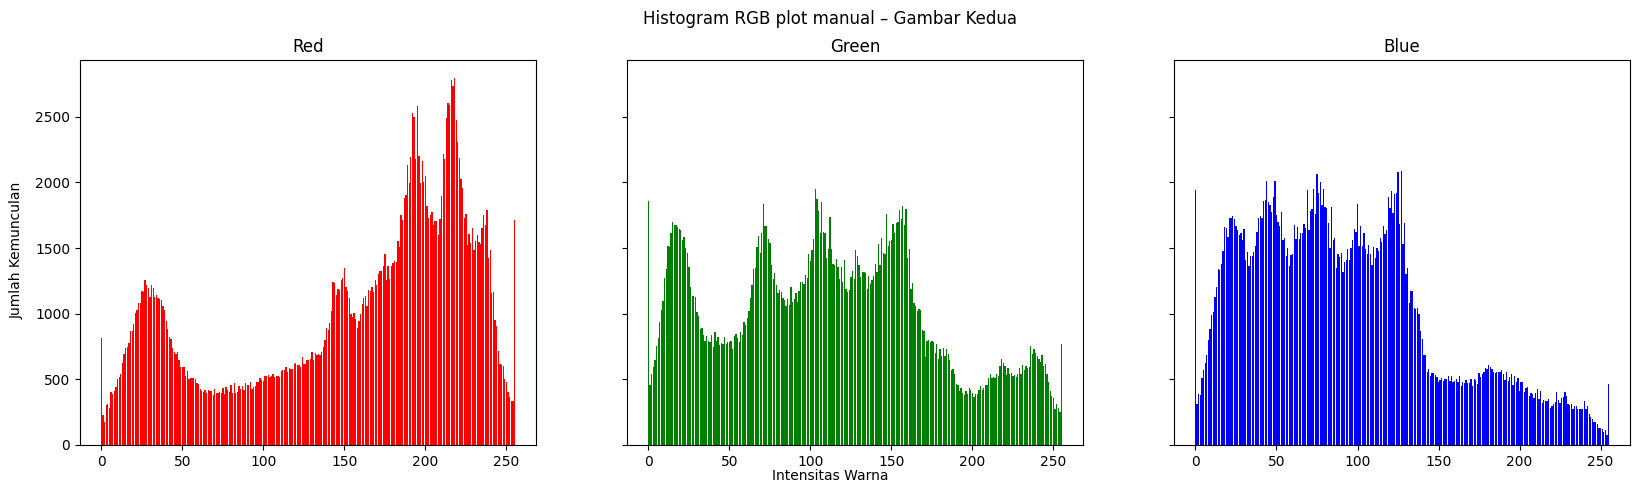

In [5]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt

# 1. Membaca gambar dan ubah ke RGB
img2 = cv.imread('/content/drive/MyDrive/images/lena.jpg')
img2 = cv.cvtColor(img2, cv.COLOR_BGR2RGB)

# 2. Inisialisasi array untuk tiap channel
h2, w2, d2 = np.shape(img2)
pixel_values = np.arange(256)

r2 = [0]*256
g2 = [0]*256
b2 = [0]*256

# 3. Loop menghitung jumlah kemunculan intensitas warna
for y in range(h2):
    for x in range(w2):
        r2[img2[y][x][0]] += 1
        g2[img2[y][x][1]] += 1
        b2[img2[y][x][2]] += 1

# 4. Plot histogram RGB
fig, axes = plt.subplots(1, 3, figsize=[20,5], sharex=True, sharey=True)
fig.suptitle('Histogram RGB plot manual – Gambar Kedua')
fig.text(0.09, 0.5, 'Jumlah Kemunculan', va='center', rotation='vertical')
fig.text(0.5, 0.04, 'Intensitas Warna', ha='center')

axes[0].bar(pixel_values, r2, color='red')
axes[0].set_title('Red')

axes[1].bar(pixel_values, g2, color='green')
axes[1].set_title('Green')

axes[2].bar(pixel_values, b2, color='blue')
axes[2].set_title('Blue')

plt.show()


# Pertanyaan Praktikum D1

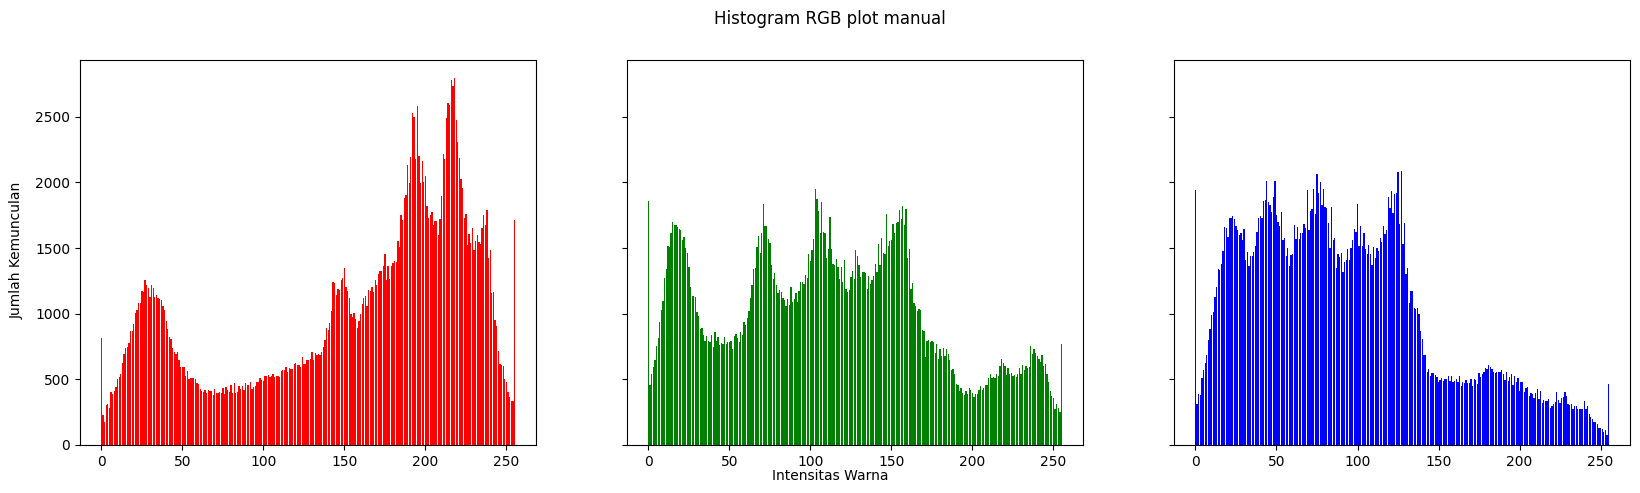

In [9]:
# 1) baca gambar & ubah ke RGB
img = cv.imread('/content/drive/MyDrive/images/lena.jpg')   # pastikan path benar
if img is None:
    raise FileNotFoundError("Gambar tidak ditemukan. Periksa path: /content/drive/MyDrive/images/lena.jpg")
img = cv.cvtColor(img, cv.COLOR_BGR2RGB)

# 2) inisialisasi
height, width, depth = np.shape(img)
names = np.arange(256)

red = [0]*256
green = [0]*256
blue = [0]*256

# 3) perhitungan histogram manual (loop y,x)
for y in range(0, height):
    for x in range(0, width):
        red[img[y][x][0]] += 1
        green[img[y][x][1]] += 1
        blue[img[y][x][2]] += 1

# 4) plotting (sama persis style materi)
fig, axs = plt.subplots(1, 3, figsize=[20,5], sharex=True, sharey=True)
fig.suptitle('Histogram RGB plot manual')
fig.text(0.09, 0.5, 'Jumlah Kemunculan', va='center', rotation='vertical')
fig.text(0.5, 0.04, 'Intensitas Warna', ha='center')
axs[0].bar(names, red, color='red')
axs[1].bar(names, green, color='green')
axs[2].bar(names, blue, color='blue')
plt.show()

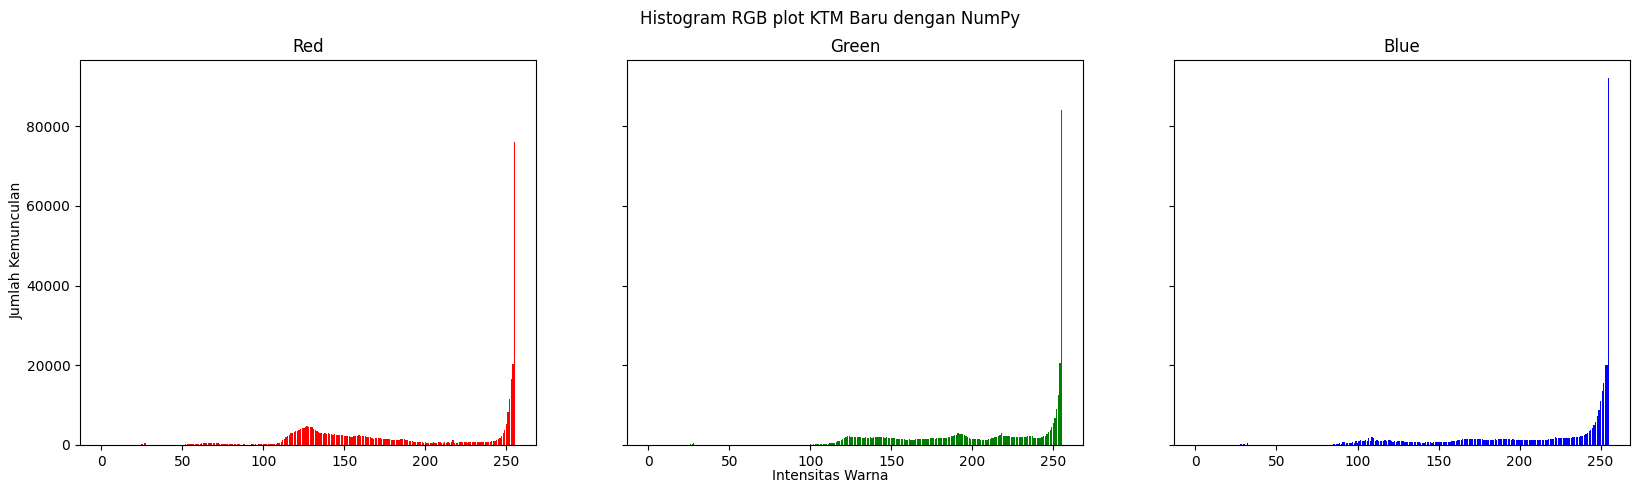

In [7]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt

# 1. Membaca gambar dan ubah ke RGB
img2 = cv.imread('/content/drive/MyDrive/images/KTM-lama.jpg')  # ganti nama file sesuai kebutuhan
img2 = cv.cvtColor(img2, cv.COLOR_BGR2RGB)

# 2. Pisahkan channel & flatten
r2 = img2[:,:,0].flatten()
g2 = img2[:,:,1].flatten()
b2 = img2[:,:,2].flatten()

# 3. Histogram dengan NumPy
hist_r2, bins_r2 = np.histogram(r2, bins=256, range=(0,256))
hist_g2, bins_g2 = np.histogram(g2, bins=256, range=(0,256))
hist_b2, bins_b2 = np.histogram(b2, bins=256, range=(0,256))

# 4. Plot hasil
fig, axes = plt.subplots(1, 3, figsize=[20,5], sharex=True, sharey=True)
fig.suptitle('Histogram RGB plot KTM Baru dengan NumPy')
fig.text(0.09, 0.5, 'Jumlah Kemunculan', va='center', rotation='vertical')
fig.text(0.5, 0.04, 'Intensitas Warna', ha='center')

axes[0].bar(range(256), hist_r2, color='red')
axes[0].set_title('Red')

axes[1].bar(range(256), hist_g2, color='green')
axes[1].set_title('Green')

axes[2].bar(range(256), hist_b2, color='blue')
axes[2].set_title('Blue')

plt.show()


# D2 PERCOBAAN HISTOGRAM EQUALIZATION

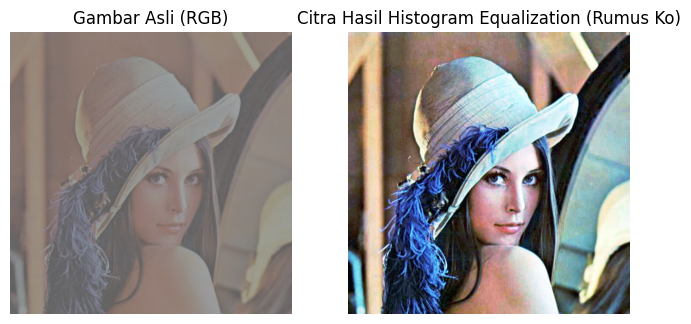

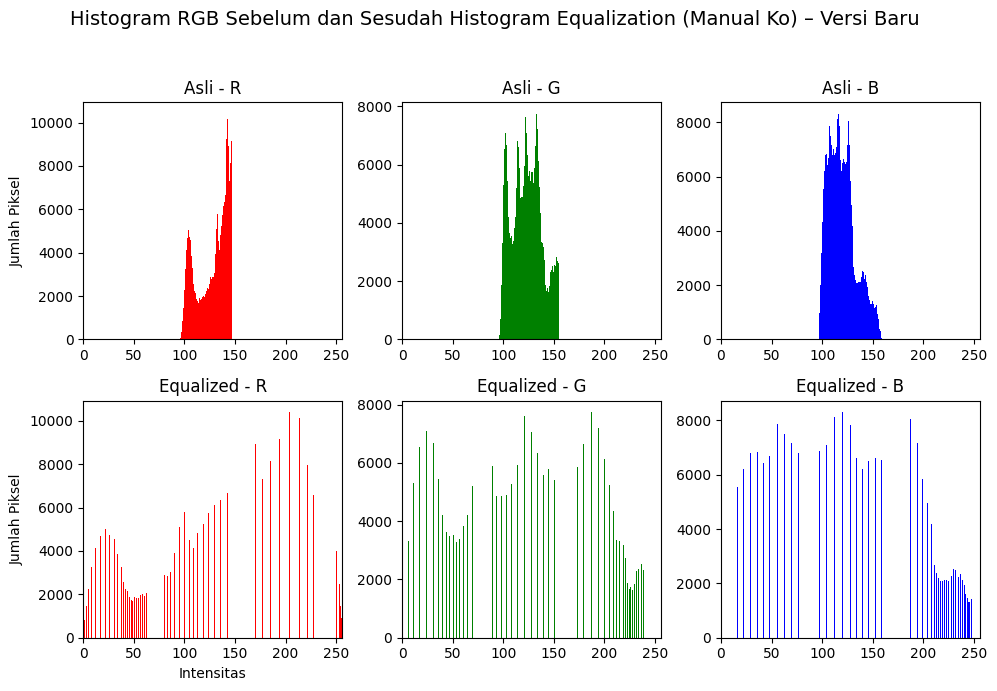

In [8]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt

# 1. Input Image
img2 = cv.imread('/content/drive/MyDrive/images/lena_lc.jpg')  # ganti nama file sesuai kebutuhan
img2 = cv.cvtColor(img2, cv.COLOR_BGR2RGB)

h2, w2, c2 = img2.shape
num_pixels2 = h2 * w2
k2 = 8
L2 = 2**k2 - 1  # 255 untuk 8-bit

# 2. Fungsi Histogram Equalization manual (per channel) rumus Ko
def manual_hist_eq_v2(channel):
    # Hitung jumlah kemunculan pixel (frekuensi)
    hist, _ = np.histogram(channel.flatten(), 256, [0,256])

    # Hitung distribusi kumulatif (CDF)
    cdf = hist.cumsum()

    # jumlah piksel
    N = channel.size

    # Rumus Ko (cdf_min)
    cdf_min = cdf[cdf > 0][0]
    mapping = np.round(((cdf - cdf_min) / (N - cdf_min)) * L2).astype('uint8')

    # Transformasi channel
    channel_eq = mapping[channel]

    return channel_eq, hist, cdf, mapping

# 3. Equalize per channel RGB
r2, g2, b2 = cv.split(img2)

r2_eq, hist_r2, cdf_r2, map_r2 = manual_hist_eq_v2(r2)
g2_eq, hist_g2, cdf_g2, map_g2 = manual_hist_eq_v2(g2)
b2_eq, hist_b2, cdf_b2, map_b2 = manual_hist_eq_v2(b2)

# 4. Gabungkan kembali
img2_eq = cv.merge((r2_eq, g2_eq, b2_eq))

# 5. Tampilkan hasil gambar sebelum & sesudah
plt.figure(figsize=(8,4))
plt.subplot(1,2,1)
plt.imshow(img2)
plt.title("Gambar Asli (RGB)")
plt.axis('off')

plt.subplot(1,2,2)
plt.imshow(img2_eq)
plt.title("Citra Hasil Histogram Equalization (Rumus Ko)")
plt.axis('off')
plt.show()

# 6. Plot Histogram Sebelum & Sesudah
colors = ('red', 'green', 'blue')
labels = ('R', 'G', 'B')

fig, axes = plt.subplots(2, 3, figsize=(10, 7))
fig.suptitle("Histogram RGB Sebelum dan Sesudah Histogram Equalization (Manual Ko) – Versi Baru", fontsize=14)

# Histogram Asli
for i, (channel, color) in enumerate(zip([r2, g2, b2], colors)):
    hist, _ = np.histogram(channel.flatten(), 256, [0,256])
    axes[0,i].bar(range(256), hist, color=color)
    axes[0,i].set_title(f"Asli - {labels[i]}")
    axes[0,i].set_xlim([0,256])
    if i == 0:
        axes[0,i].set_ylabel("Jumlah Piksel")

# Histogram Equalized
for i, (channel_eq, color) in enumerate(zip([r2_eq, g2_eq, b2_eq], colors)):
    hist, _ = np.histogram(channel_eq.flatten(), 256, [0,256])
    axes[1,i].bar(range(256), hist, color=color)
    axes[1,i].set_title(f"Equalized - {labels[i]}")
    axes[1,i].set_xlim([0,256])
    if i == 0:
        axes[1,i].set_ylabel("Jumlah Piksel")
        axes[1,i].set_xlabel("Intensitas")

plt.tight_layout(rect=[0,0,1,0.95])
plt.show()


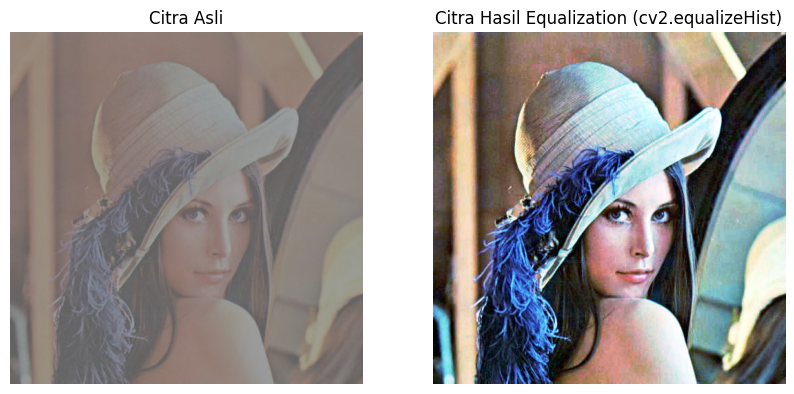

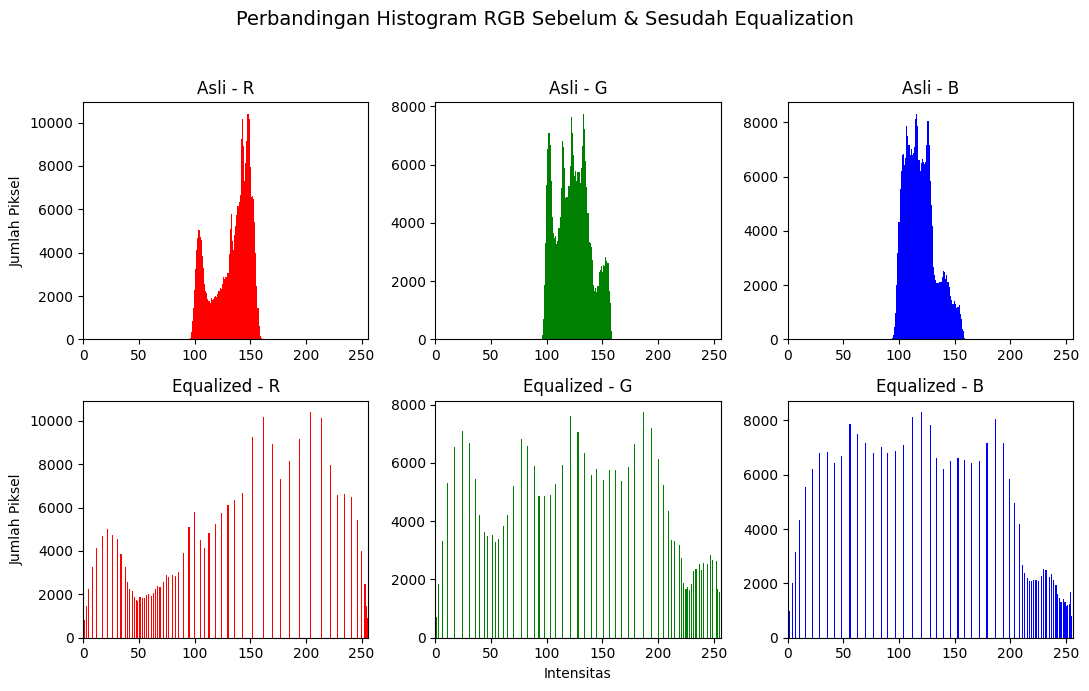

In [9]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt

# 1. Membaca gambar & konversi ke RGB
src_img = cv.imread('/content/drive/MyDrive/images/lena_lc.jpg')
src_rgb = cv.cvtColor(src_img, cv.COLOR_BGR2RGB)

# 2. Pecah menjadi tiga channel
red_ch, green_ch, blue_ch = cv.split(src_rgb)

# 3. Lakukan equalization per-channel menggunakan OpenCV
red_eq   = cv.equalizeHist(red_ch)
green_eq = cv.equalizeHist(green_ch)
blue_eq  = cv.equalizeHist(blue_ch)

# 4. Gabungkan channel hasil equalization
eq_rgb = cv.merge([red_eq, green_eq, blue_eq])

# 5. Tampilkan gambar asli dan hasil equalization
plt.figure(figsize=(10,6))
plt.subplot(1,2,1)
plt.imshow(src_rgb)
plt.title("Citra Asli")
plt.axis('off')

plt.subplot(1,2,2)
plt.imshow(eq_rgb)
plt.title("Citra Hasil Equalization (cv2.equalizeHist)")
plt.axis('off')
plt.show()

# 6. Plot histogram sebelum & sesudah
channel_names = ['R','G','B']
channel_colors = ['red','green','blue']

fig, axes = plt.subplots(2, 3, figsize=(11,7))
fig.suptitle("Perbandingan Histogram RGB Sebelum & Sesudah Equalization", fontsize=14)

# Baris pertama = histogram citra asli
for idx, (chan, col) in enumerate(zip([red_ch, green_ch, blue_ch], channel_colors)):
    hist, _ = np.histogram(chan.ravel(), bins=256, range=(0,256))
    axes[0, idx].bar(range(256), hist, color=col, width=1)
    axes[0, idx].set_title(f"Asli - {channel_names[idx]}")
    axes[0, idx].set_xlim(0,256)
    if idx == 0:
        axes[0, idx].set_ylabel("Jumlah Piksel")

# Baris kedua = histogram setelah equalization
for idx, (chan, col) in enumerate(zip([red_eq, green_eq, blue_eq], channel_colors)):
    hist, _ = np.histogram(chan.ravel(), bins=256, range=(0,256))
    axes[1, idx].bar(range(256), hist, color=col, width=1)
    axes[1, idx].set_title(f"Equalized - {channel_names[idx]}")
    axes[1, idx].set_xlim(0,256)
    if idx == 0:
        axes[1, idx].set_ylabel("Jumlah Piksel")
    if idx == 1:
        axes[1, idx].set_xlabel("Intensitas")

plt.tight_layout(rect=[0,0,1,0.95])
plt.show()


###1. Perbandingan Citra Lena
a. Gunakan hasil histogram equalization pada citra lena.jpg.

b. Hitung nilai PSNR antara citra asli dan citra hasil equalization.

c. Apakah nilai PSNR tinggi atau rendah? Apa arti nilai tersebut terhadap kualitas visual citra? Apakah ada detail baru yang muncul setelah equalization?

###2. Gunakan Citra KTM Lama.jpg
a. Terapkan histogram equalization pada citra KTM lama.jpg.

b. Tampilkan citra asli, citra hasil equalization, serta histogram keduanya
dalam satu layout.

c. Bandingkan citra KTM lama.jpg sebelum dan sesudah histogram equalization. Jelaskan perbedaan yang terlihat secara visual (misalnya pada detail wajah, teks, atau latar belakang). Apakah perubahan tersebut meningkatkan kualitas informasi dari citra atau justru membuat citra terlihat terlalu “keras”.

PSNR Lena (asli vs equalized): 17.95 dB


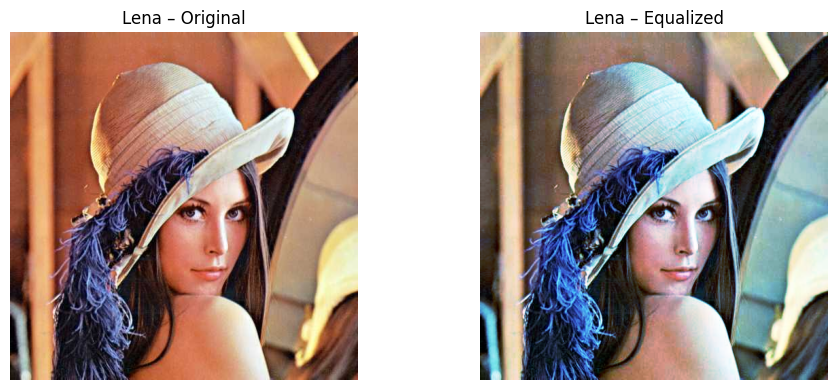

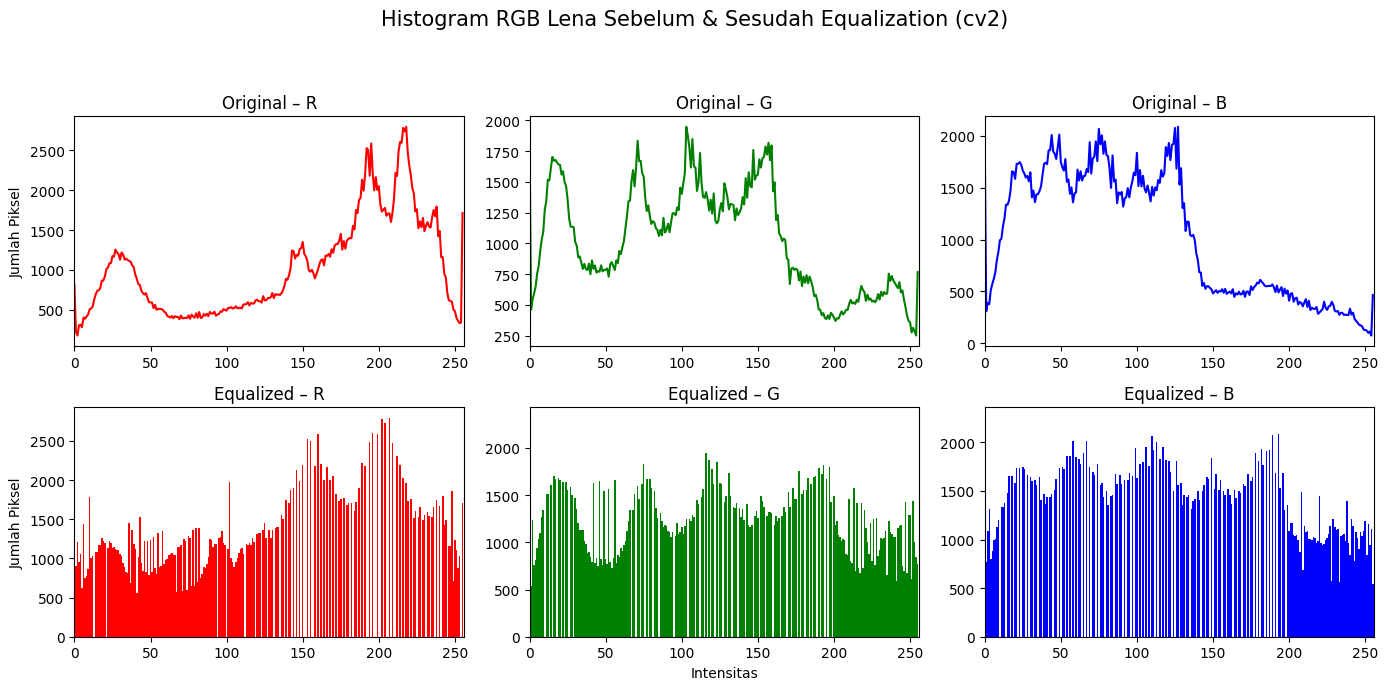

In [10]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt

# 1. Load gambar & ubah ke RGB
img_src = cv.imread('/content/drive/MyDrive/images/lena.jpg')
img_rgb = cv.cvtColor(img_src, cv.COLOR_BGR2RGB)

# 2. Split channel
ch_R, ch_G, ch_B = cv.split(img_rgb)

# 3. Equalization per channel (OpenCV)
eq_R = cv.equalizeHist(ch_R)
eq_G = cv.equalizeHist(ch_G)
eq_B = cv.equalizeHist(ch_B)

# 4. Gabungkan kembali hasil equalization
img_eq = cv.merge([eq_R, eq_G, eq_B])

# 5. Fungsi PSNR
def compute_psnr(original, processed):
    o = original.astype(np.float32)
    p = processed.astype(np.float32)
    mse = np.mean((o - p) ** 2)
    if mse == 0:
        return float('inf')
    return 10 * np.log10((255 ** 2) / mse)

# Hitung PSNR
psnr_score = compute_psnr(img_rgb, img_eq)
print(f"PSNR Lena (asli vs equalized): {psnr_score:.2f} dB")

# 6. Tampilkan citra sebelum & sesudah
plt.figure(figsize=(10,4))
plt.subplot(1,2,1)
plt.imshow(img_rgb)
plt.title("Lena – Original")
plt.axis('off')

plt.subplot(1,2,2)
plt.imshow(img_eq)
plt.title("Lena – Equalized")
plt.axis('off')
plt.tight_layout()
plt.show()

# 7. Plot histogram sebelum & sesudah
colors = ['red', 'green', 'blue']
titles  = ['R','G','B']

fig, axes = plt.subplots(2, 3, figsize=(14,7))
fig.suptitle("Histogram RGB Lena Sebelum & Sesudah Equalization (cv2)", fontsize=15)

# Baris pertama: histogram citra asli
for idx, (chan, col) in enumerate(zip([ch_R, ch_G, ch_B], colors)):
    hist, _ = np.histogram(chan.ravel(), bins=256, range=(0,256))
    axes[0, idx].plot(range(256), hist, color=col)        # diganti plot line
    axes[0, idx].set_title(f"Original – {titles[idx]}")
    axes[0, idx].set_xlim(0,256)
    if idx == 0:
        axes[0, idx].set_ylabel("Jumlah Piksel")

# Baris kedua: histogram citra equalized
for idx, (chan, col) in enumerate(zip([eq_R, eq_G, eq_B], colors)):
    hist, _ = np.histogram(chan.ravel(), bins=256, range=(0,256))
    axes[1, idx].bar(range(256), hist, color=col, width=1)
    axes[1, idx].set_title(f"Equalized – {titles[idx]}")
    axes[1, idx].set_xlim(0,256)
    if idx == 0:
        axes[1, idx].set_ylabel("Jumlah Piksel")
    if idx == 1:
        axes[1, idx].set_xlabel("Intensitas")

plt.tight_layout(rect=[0,0,1,0.93])
plt.show()


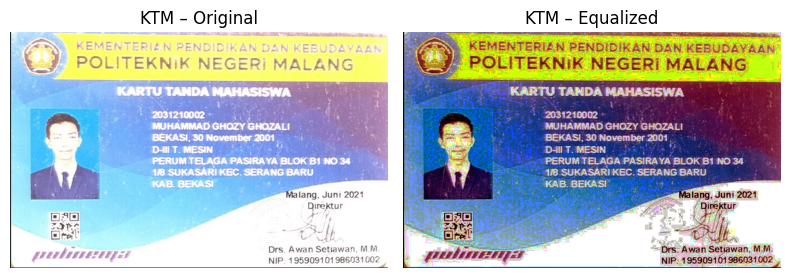

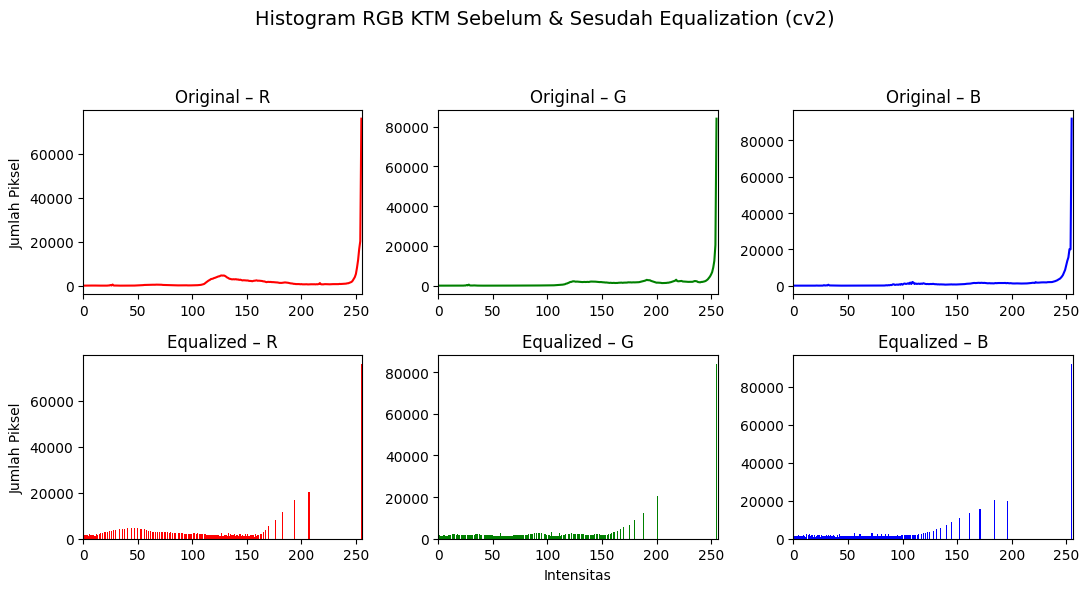

In [11]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt

# 1. Membaca citra dan konversi ke RGB
img_in = cv.imread('/content/drive/MyDrive/images/KTM-lama.jpg')
img_rgb = cv.cvtColor(img_in, cv.COLOR_BGR2RGB)

# 2. Pisahkan channel RGB
R_ch, G_ch, B_ch = cv.split(img_rgb)

# 3. Lakukan equalization untuk tiap channel
R_eq = cv.equalizeHist(R_ch)
G_eq = cv.equalizeHist(G_ch)
B_eq = cv.equalizeHist(B_ch)

# 4. Gabungkan kembali hasil equalization
img_eq = cv.merge([R_eq, G_eq, B_eq])

# 5. Tampilkan citra sebelum & sesudah
plt.figure(figsize=(8,4))
plt.subplot(1,2,1)
plt.imshow(img_rgb)
plt.title("KTM – Original")
plt.axis('off')

plt.subplot(1,2,2)
plt.imshow(img_eq)
plt.title("KTM – Equalized")
plt.axis('off')
plt.tight_layout()
plt.show()

# 6. Tampilkan histogram RGB sebelum & sesudah
colors = ['red', 'green', 'blue']
ch_names = ['R','G','B']

fig, axes = plt.subplots(2, 3, figsize=(11,6))
fig.suptitle("Histogram RGB KTM Sebelum & Sesudah Equalization (cv2)", fontsize=14)

# Baris pertama: histogram citra asli (gunakan plot garis)
for idx, (chan, col) in enumerate(zip([R_ch, G_ch, B_ch], colors)):
    hist, _ = np.histogram(chan.ravel(), bins=256, range=(0,256))
    axes[0, idx].plot(range(256), hist, color=col)
    axes[0, idx].set_title(f"Original – {ch_names[idx]}")
    axes[0, idx].set_xlim(0,256)
    if idx == 0:
        axes[0, idx].set_ylabel("Jumlah Piksel")

# Baris kedua: histogram citra setelah equalization (gunakan bar)
for idx, (chan, col) in enumerate(zip([R_eq, G_eq, B_eq], colors)):
    hist, _ = np.histogram(chan.ravel(), bins=256, range=(0,256))
    axes[1, idx].bar(range(256), hist, color=col, width=1)
    axes[1, idx].set_title(f"Equalized – {ch_names[idx]}")
    axes[1, idx].set_xlim(0,256)
    if idx == 0:
        axes[1, idx].set_ylabel("Jumlah Piksel")
    if idx == 1:
        axes[1, idx].set_xlabel("Intensitas")

plt.tight_layout(rect=[0,0,1,0.93])
plt.show()


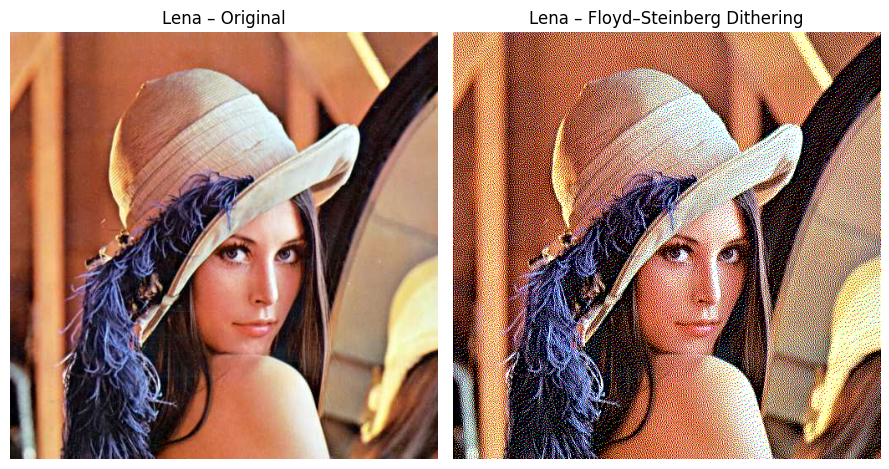

In [13]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt

# 1. Membaca gambar Lena dan konversi ke RGB
src = cv.imread('/content/drive/MyDrive/images/lena.jpg')
rgb_img = cv.cvtColor(src, cv.COLOR_BGR2RGB)
rows, cols, chs = rgb_img.shape

# 2. Siapkan salinan array bertipe float untuk proses error diffusion
fs_img = rgb_img.astype(np.float32).copy()

# 3. Implementasi Floyd–Steinberg dithering
for i in range(rows):
    for j in range(cols):
        for k in range(3):         # proses tiap channel: R, G, B
            old_val = fs_img[i, j, k]
            new_val = 255 if old_val >= 128 else 0
            fs_img[i, j, k] = new_val
            err = old_val - new_val

            # Sebar error ke piksel tetangga sesuai pola Floyd–Steinberg
            if j + 1 < cols:
                fs_img[i, j+1, k] += err * (7/16)
            if i + 1 < rows and j > 0:
                fs_img[i+1, j-1, k] += err * (3/16)
            if i + 1 < rows:
                fs_img[i+1, j, k] += err * (5/16)
            if i + 1 < rows and j + 1 < cols:
                fs_img[i+1, j+1, k] += err * (1/16)

# 4. Pastikan nilai tetap dalam rentang [0,255]
fs_img = np.clip(fs_img, 0, 255).astype(np.uint8)

# 5. Tampilkan gambar asli dan hasil dithering
plt.figure(figsize=(9,5))
plt.subplot(1,2,1)
plt.imshow(rgb_img)
plt.title("Lena – Original")
plt.axis('off')

plt.subplot(1,2,2)
plt.imshow(fs_img)
plt.title("Lena – Floyd–Steinberg Dithering")
plt.axis('off')

plt.tight_layout()
plt.show()


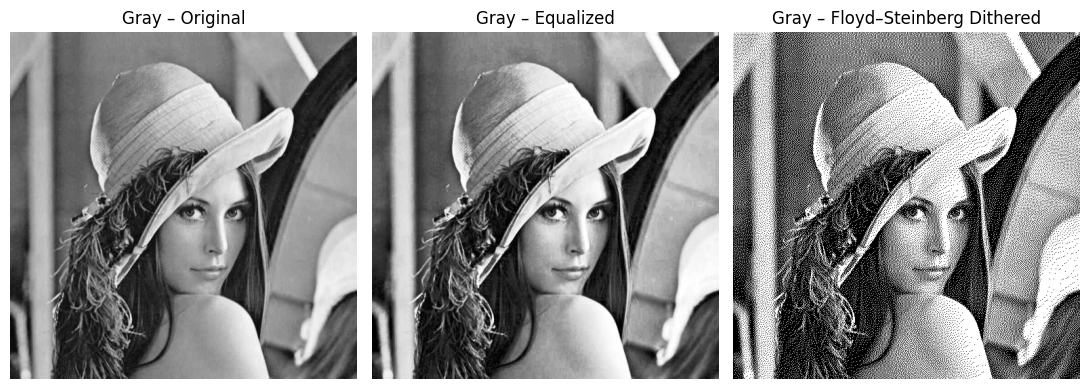

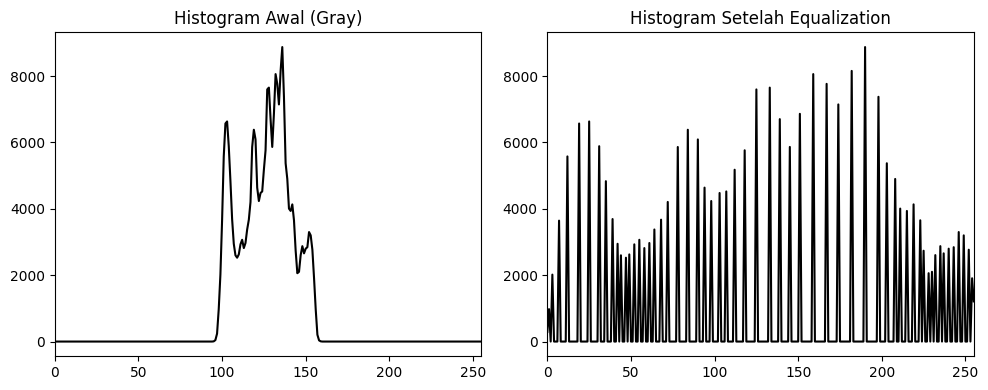

In [14]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt

# 1. Baca gambar & ubah ke grayscale
src_img = cv.imread('/content/drive/MyDrive/images/lena_lc.jpg')
gray_img = cv.cvtColor(src_img, cv.COLOR_BGR2GRAY)

# 2. Lakukan histogram equalization
gray_eq = cv.equalizeHist(gray_img)

# 3. Implementasi Floyd–Steinberg dithering
def floyd_steinberg(gray_input):
    out = gray_input.astype(np.float32).copy()
    rows, cols = out.shape
    for i in range(rows):
        for j in range(cols):
            old_val = out[i, j]
            new_val = 255 if old_val >= 128 else 0
            out[i, j] = new_val
            err = old_val - new_val

            # sebar error ke piksel tetangga
            if j + 1 < cols:
                out[i, j+1]   += err * (7/16)
            if i + 1 < rows and j > 0:
                out[i+1, j-1] += err * (3/16)
            if i + 1 < rows:
                out[i+1, j]   += err * (5/16)
            if i + 1 < rows and j + 1 < cols:
                out[i+1, j+1] += err * (1/16)

    return np.clip(out, 0, 255).astype(np.uint8)

dither_img = floyd_steinberg(gray_eq)

# 4. Tampilkan hasil citra
plt.figure(figsize=(11,4))
plt.subplot(1,3,1)
plt.imshow(gray_img, cmap='gray')
plt.title("Gray – Original")
plt.axis('off')

plt.subplot(1,3,2)
plt.imshow(gray_eq, cmap='gray')
plt.title("Gray – Equalized")
plt.axis('off')

plt.subplot(1,3,3)
plt.imshow(dither_img, cmap='gray')
plt.title("Gray – Floyd–Steinberg Dithered")
plt.axis('off')

plt.tight_layout()
plt.show()

# 5. Plot histogram sebelum & sesudah equalization
hist_before = cv.calcHist([gray_img], [0], None, [256], [0,256])
hist_after  = cv.calcHist([gray_eq], [0], None, [256], [0,256])

plt.figure(figsize=(10,4))
plt.subplot(1,2,1)
plt.plot(hist_before, color='black')
plt.title("Histogram Awal (Gray)")
plt.xlim([0,255])

plt.subplot(1,2,2)
plt.plot(hist_after, color='black')
plt.title("Histogram Setelah Equalization")
plt.xlim([0,255])

plt.tight_layout()
plt.show()
